In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("4 libraries imported successfully.")

4 libraries imported successfully.


In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/upflairs-pvt-ltd/3rd_july_datascience/refs/heads/master/farmer_guider/farmer.csv")
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [3]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
df['label'].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [6]:
group = df.groupby('label')

In [7]:
df['temperature'].min()

8.825674745

In [8]:
#to find a min of every class seperately, we will use the label group.

# group['temperature'].min()
minimum = group[['temperature']].min()


In [9]:
mean = group[['temperature']].mean()

In [10]:
maximum = group['temperature'].max()

In [11]:
temp_sample = group['temperature'].agg(['min','mean','max'])
temp_sample

,min,mean,max
label,,,
apple,21.036527,22.630942,23.996862
banana,25.010185,27.376798,29.908885
blackgram,25.097374,29.973340,34.946616
chickpea,17.024985,18.872847,20.995022
coconut,25.008724,27.409892,29.869083
coffee,23.059519,25.540477,27.923744
cotton,22.000851,23.988958,25.992374
grapes,8.825675,23.849575,41.948657
jute,23.094338,24.958376,26.985822


In [12]:
temp_sample.reset_index(inplace=True)

In [13]:
temp_sample

,label,min,mean,max
0,apple,21.036527,22.630942,23.996862
1,banana,25.010185,27.376798,29.908885
2,blackgram,25.097374,29.973340,34.946616
3,chickpea,17.024985,18.872847,20.995022
4,coconut,25.008724,27.409892,29.869083
5,coffee,23.059519,25.540477,27.923744
6,cotton,22.000851,23.988958,25.992374
7,grapes,8.825675,23.849575,41.948657
8,jute,23.094338,24.958376,26.985822
9,kidneybeans,15.330426,20.115085,24.923601


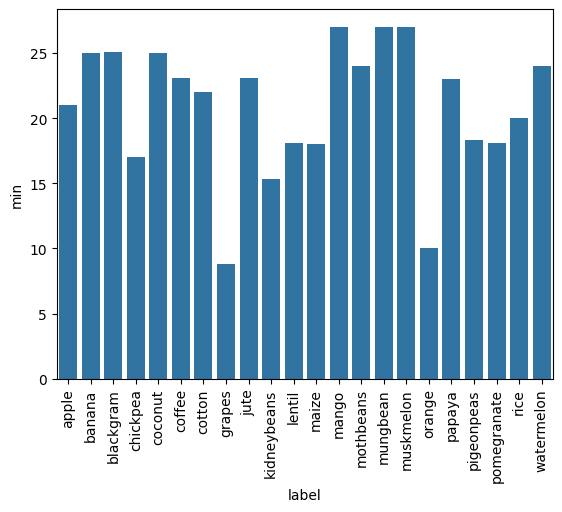

In [14]:
sns.barplot(x=temp_sample['label'],y=temp_sample['min'])
plt.xticks(rotation=90)
plt.show()

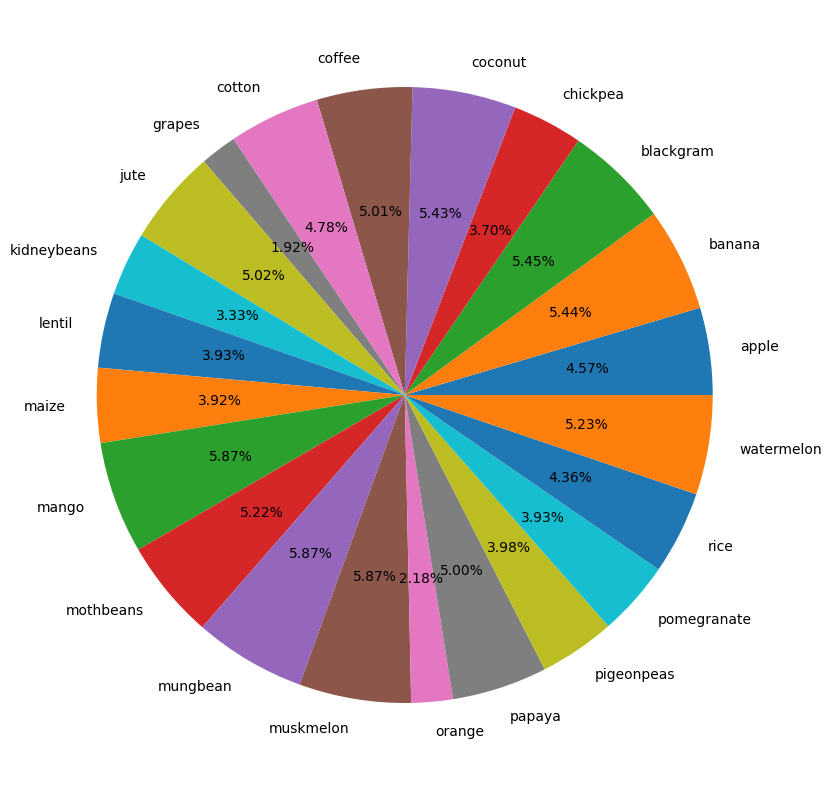

In [15]:
plt.figure(figsize=(90,10))
plt.pie(temp_sample['min'],labels=temp_sample['label'],autopct="%2.2f%%")
plt.show()

In [16]:
humid_sample = group['humidity'].agg(['min','max','mean'])
humid_sample

,min,max,mean
label,,,
apple,90.025751,94.920481,92.333383
banana,75.031933,84.978492,80.358123
blackgram,60.065349,69.961000,65.118426
chickpea,14.258040,19.969789,16.860439
coconut,90.017345,99.981876,94.844272
coffee,50.045570,69.948073,58.869846
cotton,75.005393,84.876690,79.843474
grapes,80.016394,83.983517,81.875228
jute,70.882596,89.891065,79.639864


In [17]:
humid_sample.reset_index(inplace=True)

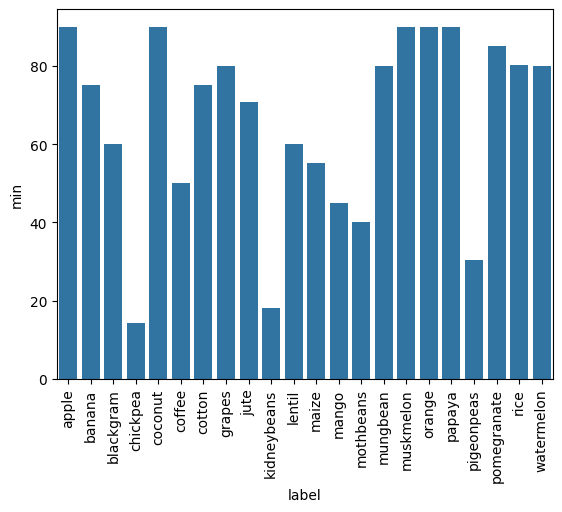

In [18]:
sns.barplot(x=humid_sample['label'],y=humid_sample['min'])
plt.xticks(rotation=90)
plt.show()

In [19]:
# y=humid_sample['min']
# x=humid_sample['label']

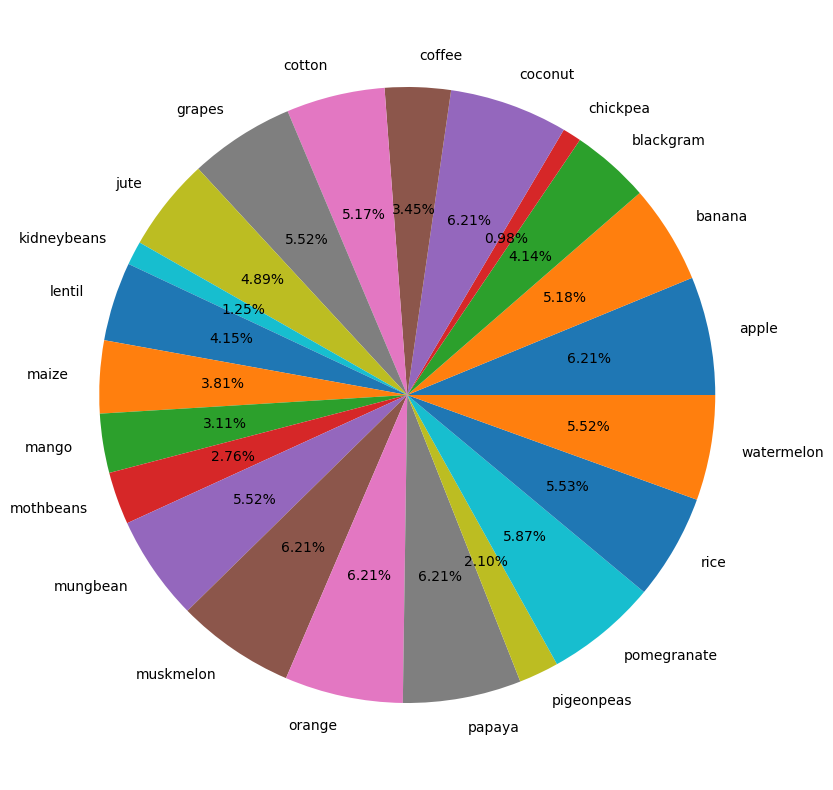

In [20]:
plt.figure(figsize=(90,10))
plt.pie(humid_sample['min'],labels=humid_sample['label'],autopct="%2.2f%%")
plt.show()

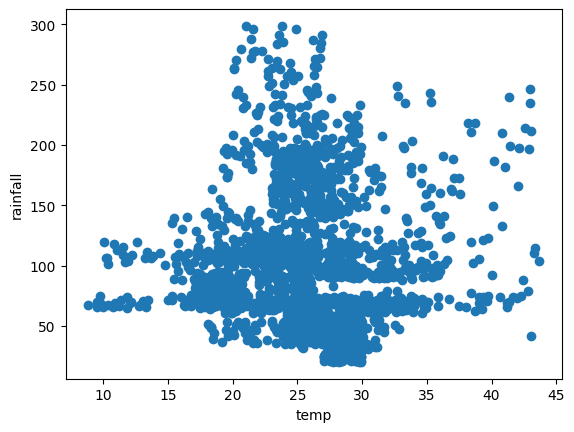

In [21]:
# plt.figure(figsize=(10,5))
plt.scatter(x=df['temperature'],y=df['rainfall'])
plt.xlabel("temp")
plt.ylabel("rainfall")
plt.show()

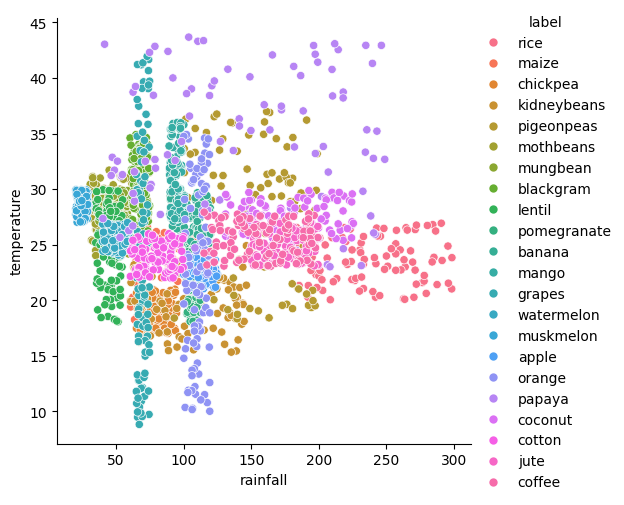

In [22]:
sns.relplot(y='temperature',x="rainfall",data=df,hue='label')

In [23]:
# a = (df['temperature']<=25)

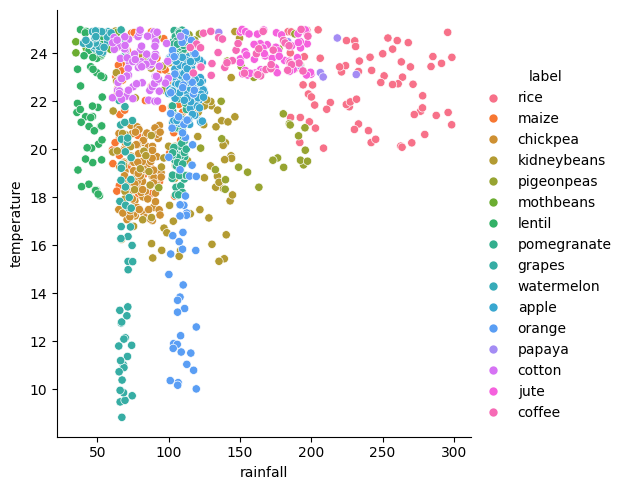

In [24]:
sns.relplot(y="temperature",x="rainfall",data=df[df['temperature']<25],hue='label')

DAY - 25

In [25]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [26]:
df2 = df.drop(['label'],axis="columns")
df2.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
std = StandardScaler()

In [29]:
std.fit(df2)

StandardScaler()

In [30]:
x = std.transform(df2)

In [31]:
x.shape

(2200, 7)

In [32]:
from sklearn.cluster import KMeans

In [33]:
kmeans = KMeans() 

In [34]:
kmeans.fit(x) #number fo groups you want

KMeans()

In [35]:
cluster_no = kmeans.labels_
cluster_no

array([5, 5, 5, ..., 5, 2, 2])

In [36]:
cluster_no.shape

(2200,)

In [37]:
df['cluster_no'] = cluster_no

In [38]:
df.to_csv('models/label_data.csv',index=False)

In [39]:
df.head(20)

,N,P,K,temperature,humidity,ph,rainfall,label,cluster_no
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,5
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,5
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,5
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,5
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,5
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice,5
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice,5
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice,5
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice,5
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice,5


In [40]:
df['cluster_no'].unique()

array([5, 2, 4, 0, 1, 7, 3, 6])

In [41]:
df['cluster_no'].value_counts()

cluster_no
1    460
2    355
5    309
0    293
7    280
3    200
6    200
4    103
Name: count, dtype: int64

In [42]:
cluster_no4 = df[df['cluster_no']==4]
cluster_no4

,N,P,K,temperature,humidity,ph,rainfall,label,cluster_no
200,40,72,77,17.024985,16.988612,7.485996,88.551231,chickpea,4
201,23,72,84,19.020613,17.131591,6.920251,79.926981,chickpea,4
202,39,58,85,17.887765,15.405897,5.996932,68.549329,chickpea,4
203,22,72,85,18.868056,15.658092,6.391174,88.510490,chickpea,4
204,36,67,77,18.369526,19.563810,7.152811,79.263577,chickpea,4
...,...,...,...,...,...,...,...,...,...
298,40,58,75,18.591908,14.779596,7.168096,89.609825,chickpea,4
299,49,69,82,18.315615,15.361435,7.263119,81.787105,chickpea,4
314,12,78,23,16.065228,18.724797,5.998125,88.066388,kidneybeans,4
438,14,74,19,18.397591,36.826393,6.624966,93.123306,pigeonpeas,4


In [43]:
cluster_no4['label'].value_counts()

label
chickpea       100
pigeonpeas       2
kidneybeans      1
Name: count, dtype: int64

In [44]:
list(cluster_no4['label'].unique())

['chickpea', 'kidneybeans', 'pigeonpeas']

In [45]:
import os, joblib

In [46]:
os.makedirs('models',exist_ok=True) #checks if the folder is there and creates one.
joblib.dump(std, 'models/std.lb') #adds file to the folder.
joblib.dump(kmeans,'models/kmeans.lb') #adds file to the folder.

['models/kmeans.lb']

In [47]:
df

,N,P,K,temperature,humidity,ph,rainfall,label,cluster_no
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,5
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,5
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,5
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,5
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,5
...,...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee,5
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee,2
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee,5
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee,2
